<br>

# Notebook 2 - Crop Simulation

<hr>
This key module simulates all the possible crop cycles to  find the best crop cycle that produces maximum yield for a particular grid. During the simulation process for each grid, 365 crop cycle simulations are performed. Each simulation corresponds to cycles that start from each day of the year (starting from Julian date 0 to Julian date 365). Similarly, this process is performed by the program for each grid in the study area. 

Prepared by Geoinformatics Center, AIT
<hr>


### Google drive connection
In this step, we will connect to Google Drive service and mount the drive where we will start our PyAEZ project

In [1]:
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

Then, installing any additional python packages that required to run PyAEZ.
If working on your own PC/machine, these additional installation will vary depending on what is already installed in your Python library. 

In [2]:
# 'Installing neccessary packages'
# !pip install gdal

Now, we will import the specific Python packages we need for PyAEZ.

In [3]:
'''import supporting libraries'''
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import xarray as xr

try:
    from osgeo import gdal
except:
    import gdal
import sys
#from joblib import Parallel, delayed

os.environ['PROJ_LIB'] = '/opt/conda/share/proj'
gdal.UseExceptions() 
np.round_ = np.round


In [4]:
from pyaez_main import initialize_aez

country_name = 'togo'
country_mask_name = 'togo_rasterized.tif'
elevation_filename = 'togo_elevation_resampled_clipped.tif'
work_dir = '/workspaces/Python-AEZ-FAO'
year = '1980'
aez = initialize_aez(work_dir, year, country_name, country_mask_name, elevation_filename, daily=True)



Available crops:
1. maize
2. rice
3. soybean
4. sugarcane
5. cassava
6. cocoa
7. coffee
8. cashew


Select a crop by number:  4


You selected: sugarcane


### Simulate crop cycle
#### Separated for Irrigated and Rainfed Routines
##### Irrigated Conditions

In [5]:
import time

np.round_ = np.round

# Start the timer
start_time = time.time()

'''run simulations'''

aez.simulateIrrigatedCropCycle(start_doy=1, end_doy=365, step_doy=1, leap_year=False)

# End the timer and calculate the duration
end_time = time.time()
execution_time = end_time - start_time

# Print the execution time
print(f"Simulation took {execution_time:.2f} seconds.")

EXECUTING sugarcane Irrigated Crop Simulation
-------------------------
Crop Type Perennial
-------------------------
Masking				=Activated
Thermal Climate Screening	=Activated
TSUM Screening			=Activated
Permafrost Screening		=Activated
Crop-specific Rule Screening	=Activated
-------------------------
Hibernation Principle		=Deactivated
-------------------------
Done:100.0 %
Irrigated Crop Simulation Completed
Simulation took 68.35 seconds.


Simulation for Sugarcane

##### Outputs from Irrigated Crop Simulation
> Introducing new outputs
1. Crop-specific total water deficit (wde)
2. Crop-specific total irrigation requirements (eta)

In [6]:
yld_irr = aez.getEstimatedYieldIrrigated() # Maximum attainable yield
fc1_irr = aez.getThermalReductionFactorIrrigated() # Fc1 factor
fc2_irr = aez.getMoistureReductionFactorIrrigated() # Fc2 factor
wde_irr = aez.getWDEIrrigated() # total water deficit
eta_irr = aez.getETAIrrigated() # total irrigation requirements 
ccd_irr = aez.getOptimumCycleStartDateIrrigated() # crop calendar

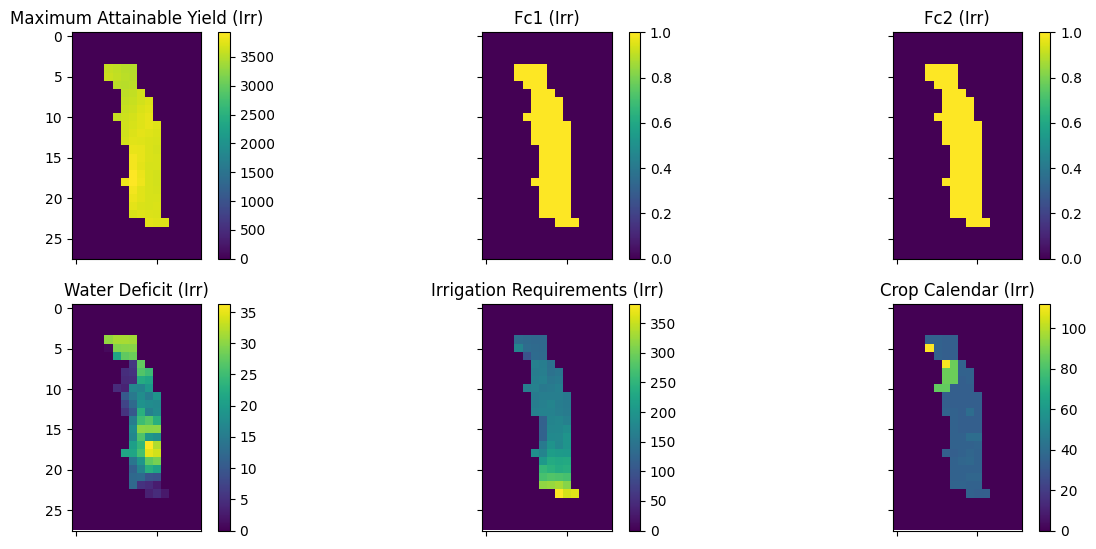

In [7]:
"""Plotting Module II Outputs"""
img_lst = [yld_irr, fc1_irr, fc2_irr, wde_irr, eta_irr, ccd_irr]
label_lst = ['Maximum Attainable Yield (Irr)', 'Fc1 (Irr)', 'Fc2 (Irr)', 'Water Deficit (Irr)',
             'Irrigation Requirements (Irr)', 'Crop Calendar (Irr)']

fig, ax = plt.subplots(3,3, sharex = True, sharey = True, figsize = (15,10))

val = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if val < len(img_lst):
            img = ax[i,j].imshow(img_lst[val], vmax = np.nanmax(img_lst[val]), vmin = 0)
            plt.colorbar(img, ax = ax[i,j])
            ax[i,j].set_title(label_lst[val])
        else:
            ax[i,j].remove()
        val +=1
plt.show()

#### Suitability Classes Determination based on Yield


Yield Classification
1.   not suitable (yields between 0% and 20%)
2.   marginally suitable (yields between 20% and 40%)
3.   moderately suitable (yields between 40% and 60%)
4. suitable (yields between 60% and 80%)
5. very suitable (yields are equivalent to 80% or more of the overall maximum yield)



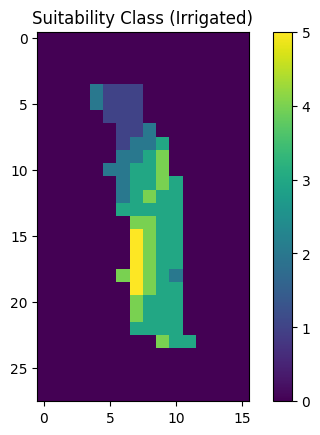

In [8]:
# get classified output of yield
from pyaez_main import classifyFinalYield

yield_map_irr_class = classifyFinalYield(yld_irr)

'''visualize result'''

"""Classified Yield"""
plt.imshow(yield_map_irr_class, vmin = 0, vmax = 5)
plt.colorbar()
plt.title('Suitability Class (Irrigated)')
plt.show()

#### Saving Module II Irrigated Results

In [23]:
'''save result'''

# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_yld_irr.tif', yld_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc1_irr.tif', fc1_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc2_irr.tif', fc2_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_wde_irr.tif', wde_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_eta_irr.tif', eta_irr)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_ccd_irr.tif', ccd_irr)

saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_yld_irr_{YEAR}.tif', yld_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc1_irr_{YEAR}.tif', fc1_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc2_irr_{YEAR}.tif', fc2_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_wde_irr_{YEAR}.tif', wde_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_eta_irr_{YEAR}.tif', eta_irr)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_ccd_irr_{YEAR}.tif', ccd_irr)

##### Simulation for Rainfed Conditions

In [9]:
# '''run simulations'''
aez.simulateRainfedCropCycle(start_doy=1, end_doy=365, step_doy=1, leap_year=False)

EXECUTING sugarcane Rainfed Crop Simulation
-------------------------
Crop Type Perennial
-------------------------
Masking				=Activated
Thermal Climate Screening	=Activated
TSUM Screening			=Activated
Permafrost Screening		=Activated
Crop-specific Rule Screening	=Activated
-------------------------
Hibernation Principle		=Deactivated
-------------------------
Done:100.0 %
Rainfed Crop Simulation Completed


Simulation for Sugarcane

##### Outputs from Rainfed Crop Simulation
> Introducing new outputs
1. Crop-specific total water deficit (wde)
2. Crop-specific total irrigation requirements (eta)

In [10]:
yld_rain = aez.getEstimatedYieldRainfed() # Maximum attainable yield
fc1_rain = aez.getThermalReductionFactorRainfed() # Fc1 factor
fc2_rain = aez.getMoistureReductionFactorRainfed() # Fc2 factor
wde_rain = aez.getWDERainfed() # total water deficit
eta_rain = aez.getETARainfed() # total irrigation requirements 
ccd_rain = aez.getOptimumCycleStartDateRainfed() # crop calendar

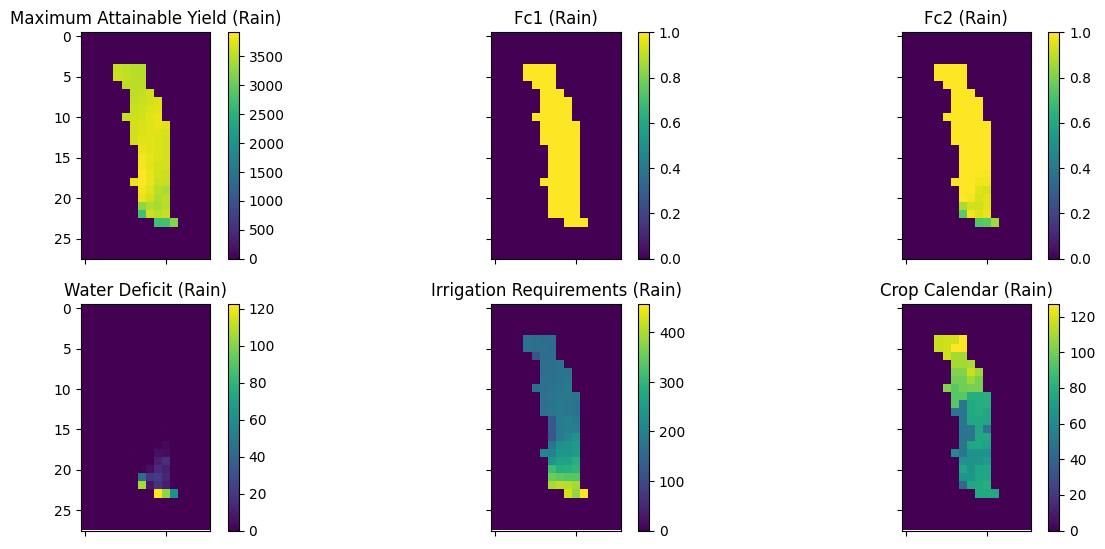

In [11]:
"""Plotting Module II Outputs"""
img_lst = [yld_rain, fc1_rain, fc2_rain, wde_rain, eta_rain, ccd_rain]
label_lst = ['Maximum Attainable Yield (Rain)', 'Fc1 (Rain)', 'Fc2 (Rain)', 'Water Deficit (Rain)',
             'Irrigation Requirements (Rain)', 'Crop Calendar (Rain)']

fig, ax = plt.subplots(3,3, sharex = True, sharey = True, figsize = (15,10))

val = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if val < len(img_lst):
            img = ax[i,j].imshow(img_lst[val], vmax = np.nanmax(img_lst[val]), vmin = 0)
            plt.colorbar(img, ax = ax[i,j])
            ax[i,j].set_title(label_lst[val])
        else:
            ax[i,j].remove()
        val +=1
plt.show()

### Suitability Classes Determination based on Yield


Yield Classification
1.   not suitable (yields between 0% and 20%)
2.   marginally suitable (yields between 20% and 40%)
3.   moderately suitable (yields between 40% and 60%)
4. suitable (yields between 60% and 80%)
5. very suitable (yields are equivalent to 80% or more of the overall maximum yield)



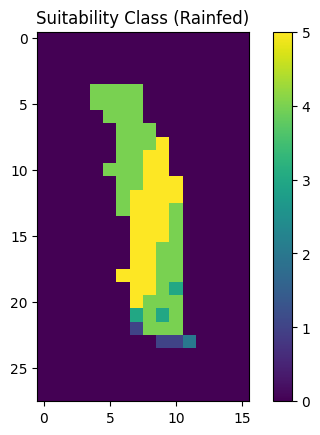

In [12]:
# get classified output of yield
yield_map_rain_class = classifyFinalYield(yld_rain)

'''visualize result'''

"""Classified Yield"""
plt.imshow(yield_map_rain_class, vmin = 0, vmax = 5)
plt.colorbar()
plt.title('Suitability Class (Rainfed)')
plt.show()

#### Saving Module II Rainfed Results

In [28]:
'''save result'''

# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_yld_rain.tif', yld_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc1_rain.tif', fc1_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_fc2_rain.tif', fc2_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_wde_rain.tif', wde_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_eta_rain.tif', eta_rain)
# saveRaster(basetifpath, r'.\data_output\NB2\New\sugc_ccd_rain.tif', ccd_rain)

saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_yld_rain_{YEAR}.tif', yld_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc1_rain_{YEAR}.tif', fc1_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_fc2_rain_{YEAR}.tif', fc2_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_wde_rain_{YEAR}.tif', wde_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_eta_rain_{YEAR}.tif', eta_rain)
saveRaster(mask_path, rf'./data_output/NB2/{country_name}_{crop_name}_ccd_rain_{YEAR}.tif', ccd_rain)

<hr>

### END OF MODULE 2: CROP SIMULATION

<hr>